## Dateset Loading

In [1]:
# data loading
import json, requests, sys

endpoint = "https://api.millercenter.org/speeches"
out_file = "speeches.json"

r = requests.post(url=endpoint)
data = r.json()
items = data['Items']

while 'LastEvaluatedKey' in data:
    parameters = {"LastEvaluatedKey": data['LastEvaluatedKey']['doc_name']}
    r = requests.post(url = endpoint, params = parameters)
    data = r.json()
    items += data['Items']
    print(f'{len(items)} speeches')

with open(out_file, "w") as out:
    out.write(json.dumps(items))
    print(f'wrote results to file: {out_file}')

95 speeches
137 speeches
175 speeches
233 speeches
275 speeches
328 speeches
369 speeches
414 speeches
460 speeches
506 speeches
550 speeches
594 speeches
625 speeches
670 speeches
716 speeches
770 speeches
807 speeches
852 speeches
902 speeches
931 speeches
984 speeches
1040 speeches
1061 speeches
wrote results to file: speeches.json


## Extract speech transcript contains China

In [3]:
pip install pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

# Read the Excel file
df = pd.read_excel('transcripts.xlsx', engine='openpyxl')

# Assume the target column is 'Transcript', replace with actual column name if different
keyword = 'China'

# Filter rows that contain the keyword "China" in the 'transcript' column
filtered_df = df[df['transcript'].str.contains(keyword, na=False)]

# Output the filtered content
print(filtered_df)
filtered_df.to_excel('Transcript_china.xlsx', index=False)

print("Filtered results have been exported to 'Transcript_china.xlsx'")


                                              doc_name  \
0           april-11-1951-report-american-people-korea   
4                october-22-1952-rear-platform-remarks   
6              january-20-1953-first-inaugural-address   
7                  february-2-1953-state-union-address   
8                           april-16-1953-chance-peace   
..                                                 ...   
478             july-24-2024-statement-american-people   
479  september-24-2024-address-79th-united-nations-...   
480                   january-15-2025-farewell-address   
481                  january-20-2025-inaugural-address   
482        march-4-2025-address-joint-session-congress   

                          date  \
0                   1951-04-11   
4                   1952-10-22   
6                   1953-01-20   
7                   1953-02-02   
8                   1953-04-16   
..                         ...   
478  2024-07-24T20:00:00-04:00   
479  2024-09-24T10:12:00-04:00 

In [1]:
pip install pandas openpyxl nltk


Note: you may need to restart the kernel to use updated packages.


## Extract China paragraphs with metadata

In [5]:
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize

# Download NLTK data (needed the first time you run it)
nltk.download('punkt')

# Read the Excel file
df = pd.read_excel('Transcript_china.xlsx')

# To store the results
results = []

# Loop through each speech record
for idx, row in df.iterrows():
    text = str(row['transcript'])
    sentences = sent_tokenize(text)

    for i, sentence in enumerate(sentences):
        if 'China' in sentence:
            # Get context of 5 sentences before and after
            start = max(0, i - 5)
            end = min(len(sentences), i + 6)
            paragraph = ' '.join(sentences[start:end])

            # Copy original metadata + new paragraph
            result = row.to_dict()
            result['china_paragraph'] = paragraph
            results.append(result)

# Convert to DataFrame
result_df = pd.DataFrame(results)

# Save to an Excel file
result_df.to_excel('china_paragraphs_with_metadata.xlsx', index=False)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zhaonianci/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### TOP 20 Frequency

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zhaonianci/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zhaonianci/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|███████████████████████████████████████| 413/413 [00:00<00:00, 1260.08it/s]


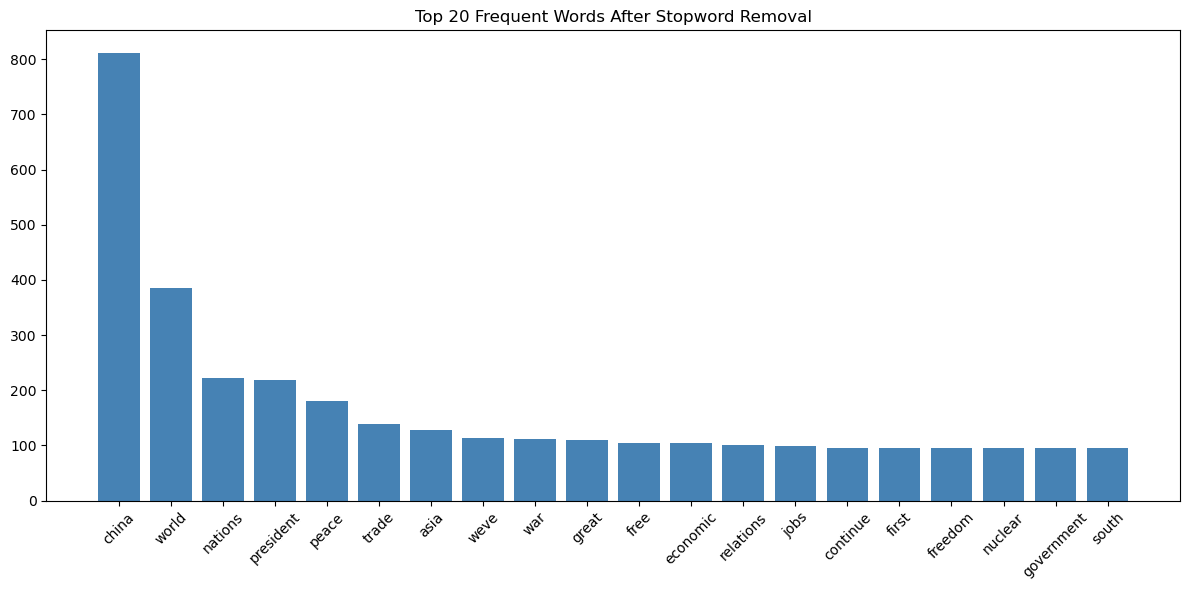

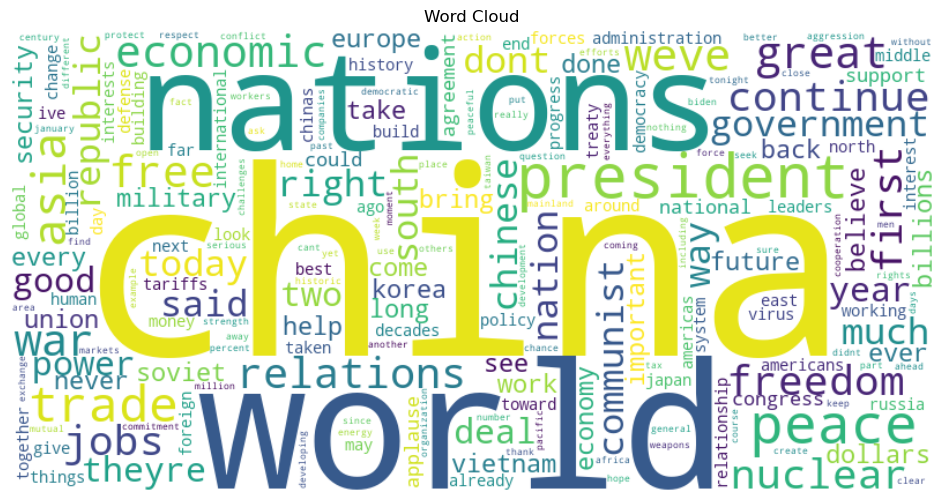

In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Read the extracted results
df = pd.read_excel('china_paragraphs_with_metadata.xlsx')

# Add progress bar with tqdm
tqdm.pandas()

# Set English stopwords
stop_words = set(stopwords.words('english'))

# Custom stopwords to filter
custom_stopwords = set([
    'america', 'american', 'word', 'one', 'must', 'new', 'just', 'make', 'get', 'united', 'states', 'would', 'country', 'countries',
    'years', 'well', 'let', 'us', 'u', 's', 'thing', 'know', 'even', 'something', 'need', 'also', 'want', 'people', 'going', 'many',
    'peoples', 'like', 'last', 'say', 'think', 'time', 'thats', 'made'
])

# Combine NLTK stopwords and custom stopwords
stop_words = stop_words.union(custom_stopwords)

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)                    # Remove newlines
    text = re.sub(r'[^a-zA-Z\s]', '', text)            # Keep only alphabets
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

# Apply text cleaning
df['clean_tokens'] = df['china_paragraph'].progress_apply(clean_text)

# Filter tokens by removing stopwords
df['filtered_tokens'] = df['clean_tokens'].apply(lambda tokens: [w for w in tokens if w not in stop_words])

# Calculate total word frequency
all_words = [word for tokens in df['filtered_tokens'] for word in tokens]
word_freq = Counter(all_words)

# Get top 20 most frequent words
top_words = word_freq.most_common(20)
words, freqs = zip(*top_words)

# Plot the frequency bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, freqs, color='steelblue')
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words After Stopword Removal")
plt.tight_layout()

# Save bar chart as image
plt.savefig("word_frequency_bar_chart.png")

# Generate the word cloud
wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")

# Save the word cloud image
#plt.savefig("word_cloud.png")

# Show the images
plt.show()


## BERTopic

In [ ]:
pip install pandas numpy sklearn-learn transformers torch umap-learn seaborn matplotlib


## Data Preprocessing

In [8]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Read the Excel file
df = pd.read_excel('china_paragraphs_with_metadata.xlsx')

# Extract the 'china_paragraph' column
texts = df['china_paragraph'].dropna().tolist()

# Text cleaning function
def clean_text(text):
    # Remove digits and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

texts_cleaned = [clean_text(text) for text in texts]

# Define a custom list of meaningless words (stopwords)
custom_stopwords = set([
    'america', 'american', 'word', 'one', 'must', 'new', 'just', 'make', 'get',
    'united', 'states', 'would', 'country', 'countries', 'years', 'well', 'let',
    'us', 'u', 's', 'thing', 'know', 'even', 'something', 'need', 'also', 'want',
    'people', 'going', 'many', 'peoples', 'like', 'last', 'say', 'think', 'time',
    'thats', 'made', "theyre", "much", "dont", "said", "come", "didnt"
])

# Load the default English stopwords list from NLTK and combine with custom stopwords
stop_words = set(nltk.corpus.stopwords.words('english')).union(custom_stopwords)

# Print the final stopwords list
#print("Final Stopwords List:", stop_words)

def remove_custom_stopwords(text):
    # Tokenize the text by spaces
    words = text.split()
    # Keep only words not in the stopwords list
    filtered_words = [word for word in words if word not in stop_words]
    # Join the filtered words back into a single string
    return " ".join(filtered_words)

# Remove stopwords from each text
texts_no_custom_stopwords = [remove_custom_stopwords(text) for text in texts_cleaned]

# Create a Lemmatizer object
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Tokenize the text by spaces
    words = text.split()
    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    # Join the lemmatized words back into a single string
    return " ".join(lemmatized_words)

# Lemmatize each text
texts_final = [lemmatize_text(text) for text in texts_no_custom_stopwords]

# Display the original and cleaned texts for the first 5 records
for i in range(5):  # Show the first 5 cleaned texts
    print(f"Original Text {i+1}: {texts[i]}")
    print(f"Cleaned Text {i+1}: {texts_final[i]}")
    print("="*50)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zhaonianci/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zhaonianci/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original Text 1: The decision is theirs, because the forces of the United Nations will strive to limit the conflict if possible. We do not want to see the conflict in Korea extended. We are trying to prevent a world war—not to start one. And the best way to do that is to make it plain that we and the other free countries will continue to resist the attack. But you may ask why can't we take other steps to punish the aggressor. Why don't we bomb Manchuria and China itself? Why don't we assist the Chinese Nationalist troops to land on the mainland of China ? If we were to do these things we would be running a very grave risk of starting a general war. If that were to happen, we would have brought about the exact situation we are trying to prevent. If we were to do these things, we would become entangled in a vast conflict on the continent of Asia and our task would become immeasurably more difficult all over the world. What would suit the ambitions of the Kremlin better than for our milit

## Train BERT Model

In [5]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load the pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Define the text encoding function
def encode_text(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

# Encode each text
embeddings = [encode_text(text) for text in texts_final]

# Check the dimensions of the embeddings
print(np.array(embeddings).shape)  # Output: (num_samples, 768)


2025-04-30 12:01:13.018841: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(413, 768)


## Use UMAP for dimensionality reduction

In [6]:
import umap

# Use UMAP for dimensionality reduction
umap_model = umap.UMAP(n_components=2, random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)

# Check the shape of the reduced data
print(reduced_embeddings.shape)  # Output: (num_samples, 2)


/Users/zhaonianci/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(413, 2)


## K-Means Cluster

/Users/zhaonianci/anaconda3/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Silhouette Score for k=2: 0.5011347532272339
Silhouette Score for k=3: 0.47223085165023804
Silhouette Score for k=4: 0.4390164613723755
Silhouette Score for k=5: 0.4348331391811371
Silhouette Score for k=6: 0.3967508375644684
Silhouette Score for k=7: 0.39795583486557007
Silhouette Score for k=8: 0.39537355303764343
Silhouette Score for k=9: 0.38369855284690857
Silhouette Score for k=10: 0.37541183829307556


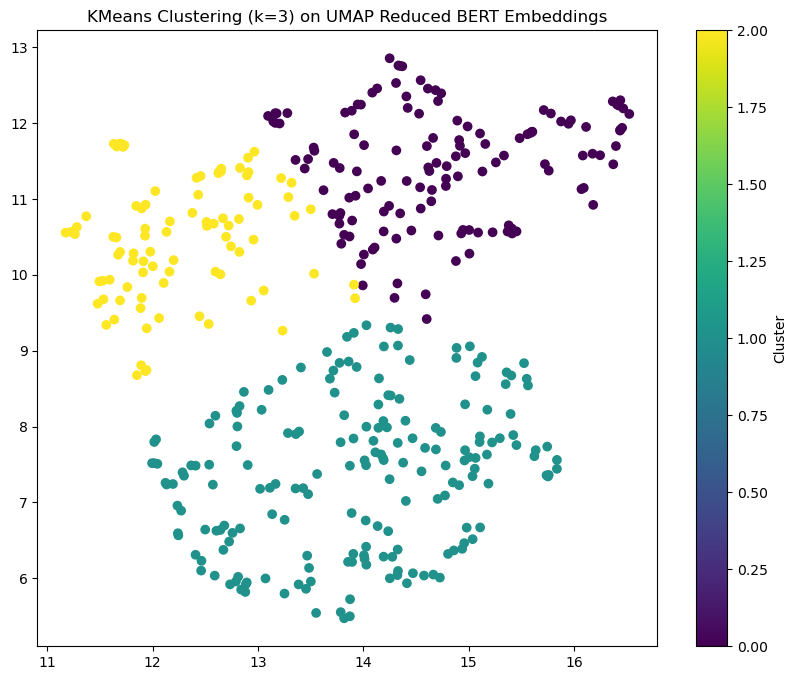

Cluster centers:
[[14.729614  11.434826 ]
 [13.924514   7.3752904]
 [12.266019  10.44678  ]]


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


inertia = []
sil_scores = []
k_range = range(1, 11)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_labels = kmeans.fit_predict(reduced_embeddings)
    
   
    inertia.append(kmeans.inertia_)
    
 
    if k > 1: 
        score = silhouette_score(reduced_embeddings, kmeans_labels)
        sil_scores.append(score)


for k, score in zip(range(2, 11), sil_scores):
    print(f"Silhouette Score for k={k}: {score}")

optimal_k = 3  


kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(reduced_embeddings)


plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(label='Cluster')
plt.title(f'KMeans Clustering (k={optimal_k}) on UMAP Reduced BERT Embeddings')
plt.show()



print("Cluster centers:")
print(kmeans.cluster_centers_)


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Assume we have obtained BERT embeddings for each text and KMeans cluster labels

# Get the embedding for each cluster center
def get_cluster_embeddings(cluster_labels, embeddings, kmeans_labels):
    cluster_embeddings = {}
    for i in range(max(kmeans_labels) + 1):
        cluster_embeddings[i] = []
    
    for i, label in enumerate(kmeans_labels):
        cluster_embeddings[label].append(embeddings[i])
    
    # Take the mean of embeddings within each cluster as the cluster center
    cluster_centers = {}
    for cluster_id, emb_list in cluster_embeddings.items():
        cluster_centers[cluster_id] = np.mean(emb_list, axis=0)
    
    return cluster_centers

# Compute cosine similarity
def compute_coherence(cluster_embeddings, embeddings, kmeans_labels):
    coherence_scores = []
    
    for cluster_id, cluster_center in cluster_embeddings.items():
        # Retrieve all text embeddings belonging to the cluster
        cluster_text_embeddings = [embeddings[i] for i in range(len(kmeans_labels)) if kmeans_labels[i] == cluster_id]
        
        # Calculate cosine similarity between each text embedding and the cluster center
        similarities = cosine_similarity([cluster_center], cluster_text_embeddings)[0]
        
        # Compute the average similarity as the coherence score for the cluster
        coherence_scores.append(np.mean(similarities))
    
    return coherence_scores

# Get the embedding for each cluster center
cluster_embeddings = get_cluster_embeddings(kmeans_labels, embeddings, kmeans_labels)

# Compute the coherence score for each cluster
coherence_scores = compute_coherence(cluster_embeddings, embeddings, kmeans_labels)

# Output the coherence score for each cluster
for i, score in enumerate(coherence_scores):
    print(f"Cluster {i} Coherence Score: {score}")


Cluster 0 Coherence Score: 0.9412539005279541
Cluster 1 Coherence Score: 0.9200016260147095
Cluster 2 Coherence Score: 0.9354655146598816


In [12]:

for cluster_num in np.unique(kmeans_labels):
    print(f"\nCluster {cluster_num}:")
    cluster_indices = np.where(kmeans_labels == cluster_num)[0]
    for idx in cluster_indices:
        print(texts_final[idx])



Cluster 0:
conflict strike directly faith father life son principle treasure hold spiritual knowledge free school church creative magic free labor capital nothing lie safely beyond reach struggle freedom pitted slavery lightness dark faith hold belongs alone free world common bond bind grower rice burma planter wheat iowa shepherd southern italy mountaineer andes confers common dignity upon french soldier dy indochina british soldier killed malaya life given korea beyond linked free merely noble idea simple free long cling privilege enjoy safety economic solitude material might market world surplus farm factory equally farm factory vital material product distant land basic law interdependence manifest commerce peace applies thousandfold intensity event war
involves serious explicit purpose foreign policy encouragement hospitable climate investment foreign nationsthird availing facility overseas economical production manufactured article needed mutual defense seriously competitive norm

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use customized TF-IDF parameters
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20,        # Increase the number of features
    min_df=2,               # Only consider words appearing in at least 2 documents
    max_df=0.8,             # Ignore words appearing in more than 80% of documents
    ngram_range=(1, 2)      # Use unigrams and bigrams
)

# Transform the text data into TF-IDF features
X_tfidf = vectorizer.fit_transform(texts_final)

# Retrieve keywords for each cluster
for cluster_num in np.unique(kmeans_labels):
    print(f"\nCluster {cluster_num}:")
    cluster_indices = np.where(kmeans_labels == cluster_num)[0]
    cluster_texts = [texts_final[idx] for idx in cluster_indices]
    
    # Compute TF-IDF scores for texts in the cluster
    tfidf_matrix = vectorizer.transform(cluster_texts)
    feature_names = vectorizer.get_feature_names_out()
    
    # Compute average TF-IDF scores for the cluster
    avg_tfidf_scores = tfidf_matrix.mean(axis=0).A1
    sorted_indices = avg_tfidf_scores.argsort()[::-1]  # Sort by score descending
    
    # Print top 10 keywords for the cluster
    top_keywords = [feature_names[i] for i in sorted_indices[:10]]
    print("Top Keywords:", top_keywords)



Cluster 0:
Top Keywords: ['world', 'nation', 'peace', 'asia', 'free', 'war', 'government', 'great', 'economic', 'power']

Cluster 1:
Top Keywords: ['job', 'billion', 'weve', 'world', 'president', 'right', 'trade', 'good', 'deal', 'way']

Cluster 2:
Top Keywords: ['president', 'war', 'communist', 'nation', 'power', 'government', 'world', 'peace', 'asia', 'right']



Cluster 0:
Top Keywords: [('china', 347), ('world', 232), ('nation', 197), ('peace', 146), ('relation', 98), ('asia', 95), ('republic', 87), ('free', 83), ('freedom', 81), ('interest', 69)]


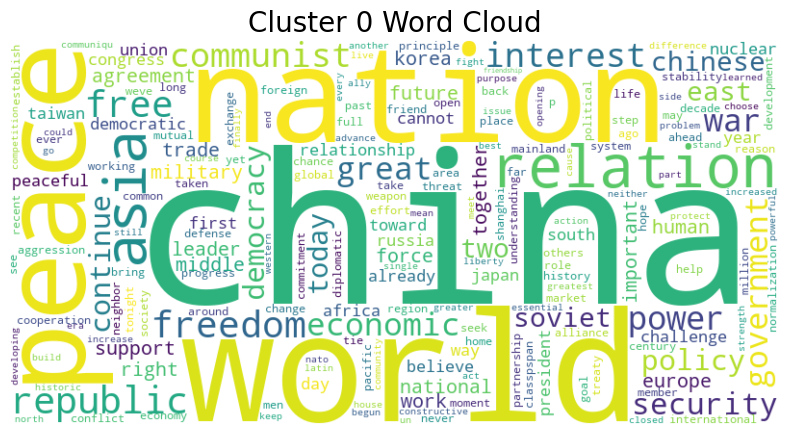

Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/kmeans_clustering_k_3.png

Cluster 1:
Top Keywords: [('china', 375), ('world', 121), ('billion', 110), ('job', 107), ('trade', 93), ('weve', 80), ('deal', 78), ('president', 77), ('dollar', 69), ('right', 69)]


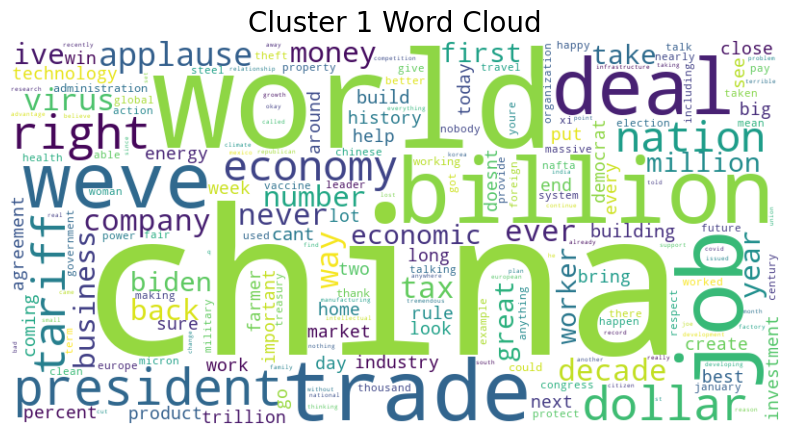

Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/kmeans_clustering_k_3.png

Cluster 2:
Top Keywords: [('china', 134), ('president', 113), ('vietnam', 73), ('nation', 60), ('nuclear', 58), ('war', 57), ('world', 55), ('communist', 53), ('south', 48), ('government', 37)]


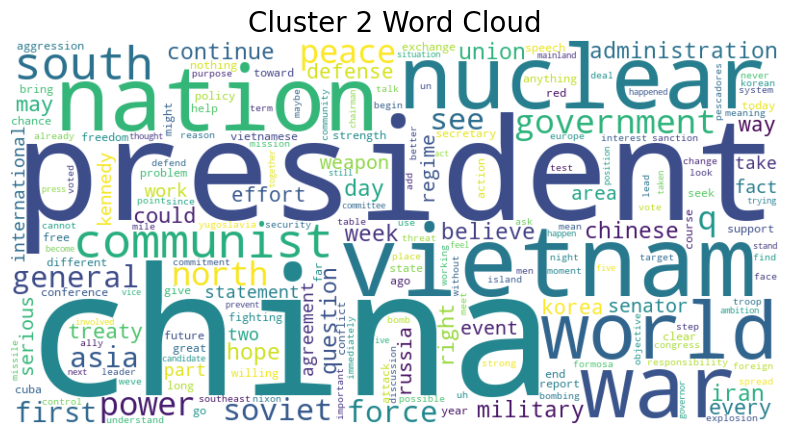

Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/kmeans_clustering_k_3.png


In [102]:
from collections import Counter
import re
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os

# Custom stopwords list
custom_stopwords = set([
    'america', 'american', 'word', 'one', 'must', 'new', 'just', 'make', 'get', "united", "states", "would", "country",
    "countries", "years", "well", "would", 'let', 'us', 'u', 's', 'thing', 'know', 'even', 'something', 'need', 'also',
    "want", "people", "going", "many", "peoples", "like", "last", "say", "think", "time", "thats", "made","theyre",
    "much","dont","said","come","didnt","mr",'case',"im","play",'good','done'
])

# Assume kmeans_labels and texts_final are already defined, where kmeans_labels are the cluster labels and texts_final is the list of texts

# Create the directory to save the images
output_dir = '/Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images'
os.makedirs(output_dir, exist_ok=True)

# Compute word frequencies and generate word clouds for each cluster
for cluster_num in np.unique(kmeans_labels):
    print(f"\nCluster {cluster_num}:")
    cluster_indices = np.where(kmeans_labels == cluster_num)[0]
    cluster_texts = [texts_final[idx] for idx in cluster_indices]
    
    # Join all texts into a single long text
    cluster_text = " ".join(cluster_texts)
    
    # Preprocess the text: remove non-alphabet characters and tokenize
    words = re.findall(r'\b\w+\b', cluster_text.lower())  # Keep only alphabetic and numeric words
    filtered_words = [word for word in words if word not in custom_stopwords]  # Remove custom stopwords
    
    # Count word frequencies
    word_counts = Counter(filtered_words)
    
    # Get the top 10 most frequent words
    top_keywords = word_counts.most_common(10)
    print("Top Keywords:", top_keywords)
    
    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
    
    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {cluster_num} Word Cloud', fontsize=20)
    plt.show()
    
    # Save the word cloud image
   # image_path = os.path.join(output_dir, f'cluster_{cluster_num}_wordcloud.png')
    #plt.savefig(image_path, format='png')
    print(f"Word cloud saved to {image_path}")



Cluster 0:
Top Keywords: [('china', 342), ('world', 228), ('nation', 196), ('peace', 145), ('relation', 98), ('asia', 98), ('republic', 87), ('freedom', 84), ('free', 83), ('interest', 69)]
Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images/cluster_0_wordcloud.png

Cluster 1:
Top Keywords: [('china', 382), ('world', 125), ('billion', 110), ('job', 108), ('trade', 93), ('weve', 84), ('president', 79), ('deal', 78), ('right', 71), ('dollar', 69)]
Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images/cluster_1_wordcloud.png

Cluster 2:
Top Keywords: [('china', 132), ('president', 113), ('vietnam', 70), ('nuclear', 58), ('nation', 57), ('war', 56), ('world', 55), ('communist', 55), ('south', 47), ('government', 37)]
Word cloud saved to /Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images/cluster_2_wordcloud.png
All clusters word cloud image saved to /Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images/all_clusters_wordclouds.png


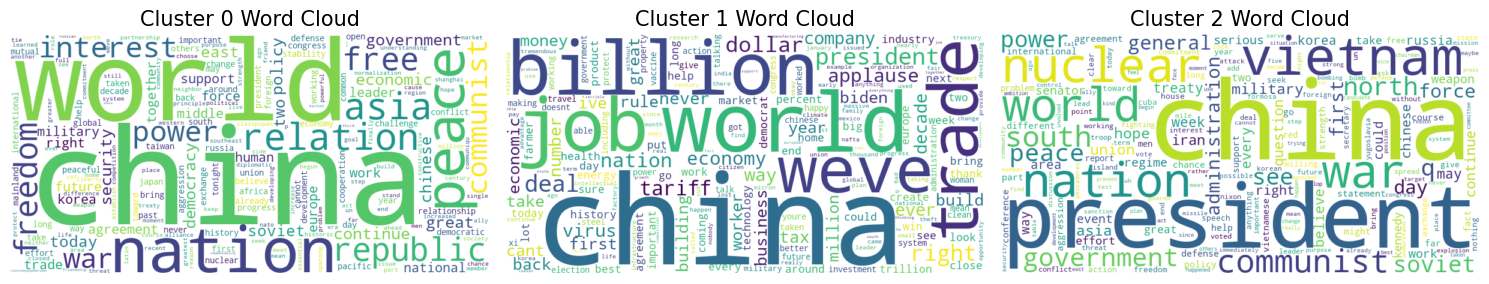

In [15]:
from collections import Counter
import re
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import os


custom_stopwords = set([
    'america', 'american', 'word', 'one', 'must', 'new', 'just', 'make', 'get', "united", "states", "would", "country",
    "countries", "years", "well", "would", 'let', 'us', 'u', 's', 'thing', 'know', 'even', 'something', 'need', 'also',
    "want", "people", "going", "many", "peoples", "like", "last", "say", "think", "time", "thats", "made","theyre",
    "much","dont","said","come","didnt","mr",'case',"im","play",'good','done'
])


output_dir = '/Users/zhaonianci/Desktop/CSS5230/final/wordcloud_images'
os.makedirs(output_dir, exist_ok=True)


plt.figure(figsize=(15, 10))


for cluster_num in np.unique(kmeans_labels):
    print(f"\nCluster {cluster_num}:")
    cluster_indices = np.where(kmeans_labels == cluster_num)[0]
    cluster_texts = [texts_final[idx] for idx in cluster_indices]
    
  
    cluster_text = " ".join(cluster_texts)
    
 
    words = re.findall(r'\b\w+\b', cluster_text.lower())  
    filtered_words = [word for word in words if word not in custom_stopwords] 
    
   
    word_counts = Counter(filtered_words)
    
   
    top_keywords = word_counts.most_common(10)
    print("Top Keywords:", top_keywords)
    
 
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
    
 
    plt.subplot(2, 3, cluster_num + 1)  
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Cluster {cluster_num} Word Cloud', fontsize=15)
    
   
    image_path = os.path.join(output_dir, f'cluster_{cluster_num}_wordcloud.png')
    wordcloud.to_file(image_path)
    print(f"Word cloud saved to {image_path}")

plt.tight_layout()


whole_image_path = os.path.join(output_dir, 'all_clusters_wordclouds.png')
plt.savefig(whole_image_path, format='png')
print(f"All clusters word cloud image saved to {whole_image_path}")

plt.show()
